# Participant 1: standardized comparison of three hierarchical observers

This notebook compares three implementations under one observation model. Every
model receives the same chronological participant-1 trials, coherence, true
direction feedback, session boundaries, response grid, motor-noise process,
lapse process, optimizer, and score calculation.

The experimenter's `prior_std` label is neither passed to nor retained by any
observer. State resets at session boundaries and carries across blocks within a
session. Parameters are fitted by maximum likelihood; "hierarchical" refers to
the observer's latent prior-confidence structure, not population-level partial
pooling across participants.

## Models and equations

Let (d_t) be the true direction, (m_t) an internal measurement,
(mu_0=225^circ), and (VM(cdot;mu,kappa)) a von Mises distribution.

**Readout-average** forms a contaminated direction prior for each candidate
precision,

\[
\pi_\kappa(\theta)=\alpha VM(\theta;\mu_0,\kappa)+(1-\alpha)U(\theta),
\]

takes a MAP readout conditional on each \(\kappa\), and averages the resulting
response distributions using \(b_t(\kappa)\).

**Reliability-mixture** directly mixes a prior-centered and stimulus-centered
component,

\[
p(q_t)=r_tVM(q_t;\mu_0,\kappa_p)+(1-r_t)VM(q_t;d_t,\kappa_e[c_t]),
\]

where \(r_t\) follows a five-feedback delta-rule update. The standardized
version has one fitted \(\kappa_p\), not four `prior_std`-indexed values.

**Integrated-prior** first marginalizes precision uncertainty,

\[
\pi_t(\theta)=\sum_\kappa H_t(\kappa)VM(\theta;\mu_0,\kappa),
\]

then forms one posterior

\[
p(\theta\mid m_t,H_t)\propto VM(\theta;m_t,\kappa_e[c_t])\pi_t(\theta)
\]

and applies one tie-aware MAP readout.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "src" / "standardized_hb").exists():
            return candidate
        nested = candidate / "standardized_hierarchical_comparison"
        if (nested / "src" / "standardized_hb").exists():
            return nested
    raise FileNotFoundError("Could not locate standardized_hierarchical_comparison.")


PROJECT_ROOT = find_project_root(Path.cwd())
WORKSPACE_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from standardized_hb import (
    FitConfig,
    GridSpec,
    IntegratedPriorObserver,
    ReadoutAverageObserver,
    ReliabilityMixtureObserver,
    fit_model,
    load_participant,
)
from standardized_hb.plotting import comparison_figure, state_figure

print("project:", PROJECT_ROOT)

project: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison


## Run configuration

The normal run fits all 8,562 participant-1 trials with two starts per model.
`HB_SMOKE_TEST=1` retains the full trial sequence but limits optimizer
evaluations, making it suitable for checking the complete pipeline.

In [2]:
SMOKE_TEST = os.environ.get("HB_SMOKE_TEST", "0") == "1"
GRID = GridSpec(
    n_angles=72,
    n_positive_kappa=9,
    kappa_min=0.05,
    kappa_max=50.0,
    prior_mean_degrees=225.0,
)
FIT_CONFIG = FitConfig(
    n_starts=1 if SMOKE_TEST else 2,
    max_evaluations_per_start=5 if SMOKE_TEST else 60,
    seed=20260721,
)
RUN_LABEL = "smoke" if SMOKE_TEST else "participant_1"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

run_config = {
    "smoke_test": SMOKE_TEST,
    "participant_id": 1,
    "n_angles": GRID.n_angles,
    "angle_step_degrees": 360.0 / GRID.n_angles,
    "kappa_support": GRID.kappa_values.tolist(),
    "n_starts": FIT_CONFIG.n_starts,
    "max_evaluations_per_start": FIT_CONFIG.max_evaluations_per_start,
    "prior_std_used": False,
    "state_reset": "session boundary",
    "state_carryover": "across blocks within a session",
}
display(pd.DataFrame.from_dict(run_config, orient="index", columns=["value"]))

,value
smoke_test,False
participant_id,1
n_angles,72
angle_step_degrees,5.0
kappa_support,"[0.0, 0.05, 0.11856868528308274, 0.28117066259..."
n_starts,2
max_evaluations_per_start,60
prior_std_used,False
state_reset,session boundary
state_carryover,across blocks within a session


## Load participant 1

The loader intentionally has no `prior_std` field. Missing responses would be
excluded from scoring but their true-direction feedback would still update the
latent state.

In [3]:
DATA_CANDIDATES = [
    WORKSPACE_ROOT / "hierarchical" / "data" / "data01_direction4priors.csv",
    Path.home() / "Downloads" / "data01_direction4priors.csv",
]
DATA_CSV = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_CSV is None:
    raise FileNotFoundError(f"Data not found. Checked: {DATA_CANDIDATES}")

subject, audit = load_participant(DATA_CSV, subject_id=1, grid=GRID)
assert not hasattr(subject, "prior_std")
assert audit["prior_std_used"] is False
display(pd.DataFrame.from_dict(audit, orient="index", columns=["value"]))

,value
csv_path,C:\Users\HP\Desktop\baysiean hyperprior\hierar...
subject_id,1
trials,8562
valid_responses,8562
sessions,8
runs,40
coherences,"[0.06, 0.12, 0.24]"
prior_mean_degrees,225.0
prior_std_used,False


## Construct the three observers and validate their default predictions

In [4]:
observers = {
    "readout_average": ReadoutAverageObserver(subject, GRID, batch_size=128),
    "reliability_mixture": ReliabilityMixtureObserver(subject, GRID, batch_size=128),
    "integrated_prior": IntegratedPriorObserver(subject, GRID, batch_size=128),
}

preflight = []
for name, observer in observers.items():
    started = perf_counter()
    raw = observer.default_raw_parameters()
    prediction = observer.predict(raw)
    row_sums = prediction.response_pmfs.sum(axis=1)
    nll = observer.negative_log_likelihood(raw)
    preflight.append(
        {
            "model": name,
            "parameters": observer.parameter_count,
            "default_nll": nll,
            "maximum_normalization_error": float(np.max(np.abs(row_sums - 1.0))),
            "elapsed_seconds": perf_counter() - started,
        }
    )
preflight_table = pd.DataFrame(preflight)
assert (preflight_table["maximum_normalization_error"] < 1e-10).all()
display(preflight_table)

,model,parameters,default_nll,maximum_normalization_error,elapsed_seconds
0,readout_average,7,25743.062471,4.440892e-16,0.695370
1,reliability_mixture,7,28906.455633,4.440892e-16,0.855384
2,integrated_prior,6,25953.904906,4.440892e-16,10.376383


## Fit all three models

Each optimizer sees the same trials and transformed parameter bounds. AIC and
BIC are comparable here because response binning and lapse likelihood are
identical across models.

In [5]:
fit_results = {}
for name, observer in observers.items():
    print(f"Fitting {name} ...", flush=True)
    result = fit_model(observer, FIT_CONFIG)
    fit_results[name] = result
    print(
        f"  NLL={result.nll:.2f}, AIC={result.aic:.2f}, "
        f"evaluations={result.evaluations}, elapsed={result.elapsed_seconds:.1f}s",
        flush=True,
    )

Fitting readout_average ...
  NLL=24927.03, AIC=49868.06, evaluations=120, elapsed=22.8s
Fitting reliability_mixture ...
  NLL=28385.92, AIC=56785.84, evaluations=120, elapsed=35.3s
Fitting integrated_prior ...
  NLL=25138.85, AIC=50289.70, evaluations=120, elapsed=659.0s


## Compare scores and fitted parameters

In [6]:
score_table = pd.DataFrame(
    [
        {
            "model": name,
            "n_parameters": observers[name].parameter_count,
            "nll": result.nll,
            "aic": result.aic,
            "bic": result.bic,
            "delta_aic": result.aic - min(item.aic for item in fit_results.values()),
            "evaluations": result.evaluations,
            "elapsed_seconds": result.elapsed_seconds,
            "optimizer_success": result.success,
        }
        for name, result in fit_results.items()
    ]
).sort_values("aic").reset_index(drop=True)
display(score_table)

parameter_table = pd.DataFrame(
    {name: result.parameters for name, result in fit_results.items()}
).T
display(parameter_table)

,model,n_parameters,nll,aic,bic,delta_aic,evaluations,elapsed_seconds,optimizer_success
0,readout_average,7,24927.029880,49868.059760,49917.445384,0.000000,120,22.802294,False
1,integrated_prior,6,25138.849341,50289.698682,50332.029216,421.638922,120,659.047484,False
2,reliability_mixture,7,28385.917778,56785.835556,56835.221180,6917.775796,120,35.321216,False


,alpha,motor_kappa,lapse,lambda,sensory_kappa_0.06,sensory_kappa_0.12,sensory_kappa_0.24,prior_kappa,learning_rate,rho
readout_average,0.6,30.0,0.02,0.05,2.786372,13.372092,79.971451,NaN,NaN,NaN
reliability_mixture,NaN,30.0,0.02,NaN,8.286514,32.720355,79.969474,2.7,0.1,NaN
integrated_prior,NaN,30.0,0.02,NaN,2.712374,12.042812,12.000000,NaN,NaN,0.844253


## Generate and save fitted trial-level predictions

In [7]:
predictions = {
    name: observers[name].predict(result.raw_parameters)
    for name, result in fit_results.items()
}

payload = {
    "run_config": run_config,
    "data_audit": audit,
    "fits": {name: result.summary_record() for name, result in fit_results.items()},
}
with (OUTPUT_DIR / "fit_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(payload, handle, indent=2, default=lambda value: value.item() if hasattr(value, "item") else str(value))

score_table.to_csv(OUTPUT_DIR / "model_scores.csv", index=False)
parameter_table.to_csv(OUTPUT_DIR / "fitted_parameters.csv", index=True)
for name, result in fit_results.items():
    result.history.to_csv(OUTPUT_DIR / f"{name}_optimization_history.csv", index=False)
    np.savez_compressed(
        OUTPUT_DIR / f"{name}_predictions.npz",
        response_pmfs=predictions[name].response_pmfs,
        state=predictions[name].state,
        raw_parameters=result.raw_parameters,
    )
print("saved:", OUTPUT_DIR)

saved: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison\outputs\participant_1


## Observed and predicted response distributions

The left panel compares penalized fit. The middle panel aggregates all responses
relative to the fixed prior mean. The right panel selects the most frequent
low-coherence direction at least 60 degrees from the prior, where differences
in bimodality are easiest to inspect.

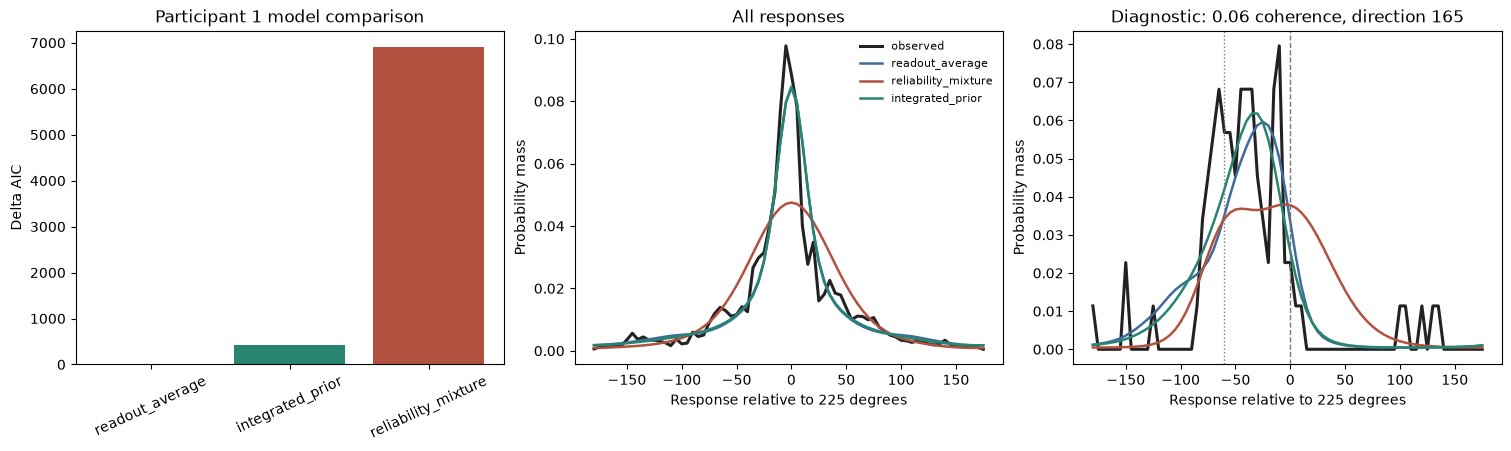

In [8]:
figure = comparison_figure(subject, GRID, predictions, score_table)
figure.savefig(OUTPUT_DIR / "response_and_score_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Learned state trajectories

The two kappa-learning models report expected prior concentration. The
reliability-mixture model reports its scalar prior reliance. Gray lines mark
session boundaries, where every model is reset under the shared contract.

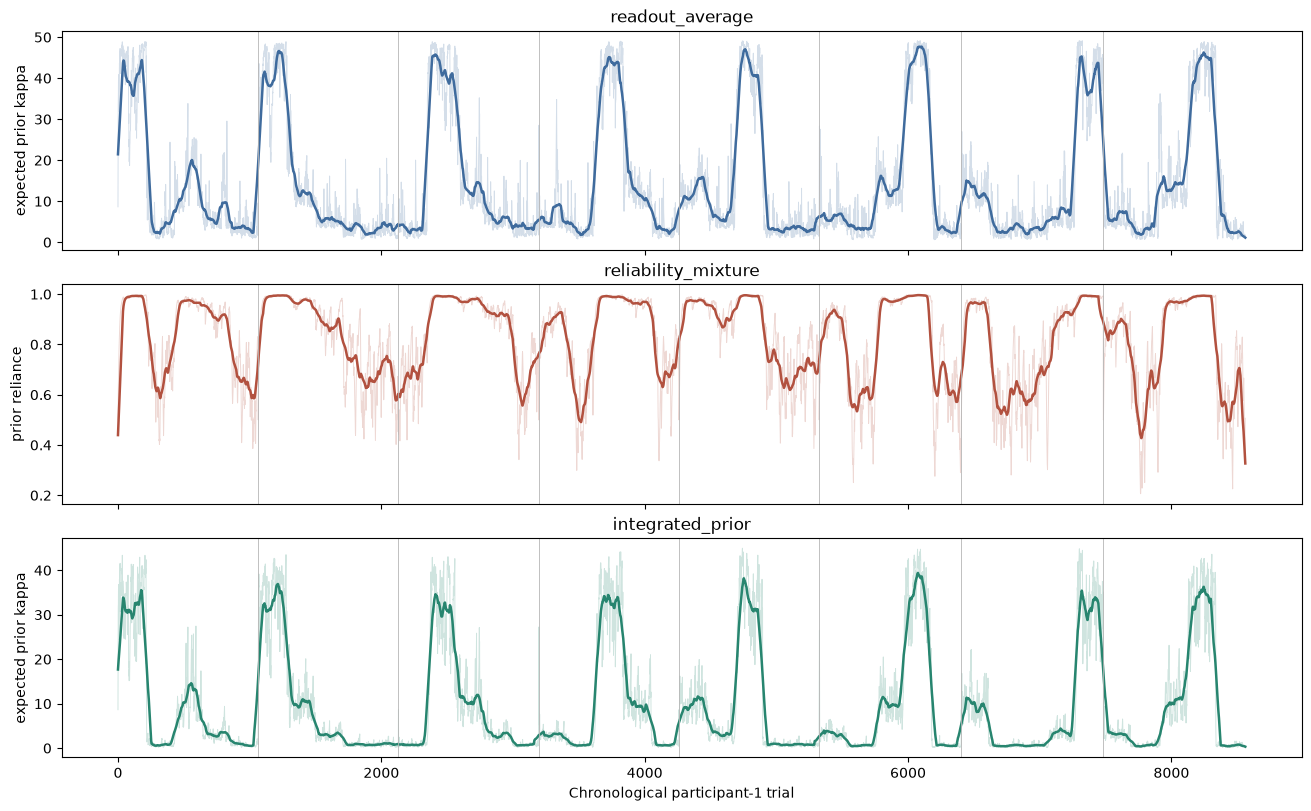

In [9]:
figure = state_figure(subject, predictions, smoothing_window=75)
figure.savefig(OUTPUT_DIR / "learned_state_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretation gate

- A lower AIC/BIC is evidence for a better penalized in-sample description, not
  proof of the cognitive mechanism.
- Inspect the diagnostic response shape and state trajectory together. Similar
  likelihoods can hide different mechanisms.
- A full scientific comparison should add sequence-preserving held-out scoring
  and parameter recovery under this same standardized contract.
- Smoke-mode scores are pipeline checks and must not be reported as final fits.